A plot is an argument built from observations. To evaluate it, ask what each mark represents, what comparison the display supports, and what the data cannot establish.

This chapter develops individual plots with Pandas, Matplotlib's pyplot interface, and Seaborn. [Data Visualization Intermediate](Advanced_Data_Visualization.ipynb) builds on these skills with explicit Axes control, subplots, facets, and a geospatial extension for final projects.

## Learning Objectives

By the end of this chapter, you should be able to:

- Choose a plot from the question, observational unit, and variable types.
- Distinguish counts, proportions, distributions, and estimated group means.
- Create and label individual plots using Pandas, pyplot, and Seaborn.
- Explain bins, boxplot whiskers, and the difference between spread and uncertainty.
- Describe an association without claiming causation.
- Evaluate scales, colors, missing observations, and the population a plot represents.

## Set Up the Chapter Files {#set-up-the-chapter-files}

Run the notebook from the coursebook folder, with `Datasets/` beside it. The main examples use [Australia_weather.csv](Datasets/Australia_weather.csv); transfer examples use [covid.csv](Datasets/covid.csv), [survey_data_clean.csv](Datasets/survey_data_clean.csv), and [fifa_data.csv](Datasets/fifa_data.csv). These are historical teaching datasets, not live data feeds. Their availability does not imply a random or representative sample.

In your activated project environment, install the core packages if needed:

```bash
python -m pip install pandas numpy matplotlib seaborn
```

Use Seaborn 0.12 or later for the `errorbar` interface and Matplotlib 3.9 or later for `tick_labels`. Select that environment as your notebook kernel. Run cells from top to bottom; setup and data preparation cells are reused below.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

DATA = Path("Datasets")
sns.set_theme(style="whitegrid", palette="colorblind", context="notebook")
plt.rcParams.update({"figure.figsize": (8, 5), "figure.dpi": 100})
print({"pandas": pd.__version__, "matplotlib": matplotlib.__version__, "seaborn": sns.__version__})

{'pandas': '3.0.5', 'matplotlib': '3.11.2', 'seaborn': '0.13.2'}


### One Table, Several Questions

One weather row represents a recorded day at a location. `MaxTemp` and `MinTemp` are temperatures in °C; `Rainfall` is in mm; `Location` is categorical; `Date` is a date. Numeric values can be discrete (such as counts) or continuous. A numeric code can still represent a category.

We select three cities, parse the dates, and inspect usable observation counts. Missing temperatures will not become zero-temperature days: plots of those temperatures exclude missing values. Counts can therefore differ from one plot to another.

In [2]:
weather = pd.read_csv(DATA / "Australia_weather.csv")
weather["Date"] = pd.to_datetime(weather["Date"], format="%m/%d/%Y")
cities = ["Sydney", "Canberra", "Melbourne"]
city_weather = weather.loc[weather["Location"].isin(cities)].copy()
city_colors = dict(zip(cities, sns.color_palette("colorblind", 3)))
city_weather.groupby("Location").agg(
    rows=("Date", "size"),
    valid_max_temp=("MaxTemp", "count"),
    first_date=("Date", "min"),
    last_date=("Date", "max"),
).reindex(cities)

,rows,valid_max_temp,first_date,last_date
Location,,,,
Sydney,1690,1690,2010-10-20,2017-06-25
Canberra,1078,1078,2007-11-01,2012-11-28
Melbourne,1898,1898,2008-07-01,2017-06-25


## Choose a Plot from the Question {#choose-a-plot}

Before coding, finish this sentence: **Each row represents ___, and I want to compare ___.** Then identify the variables and the summary, if any.

| Question | Variables | Useful starting plot | What one mark represents |
|---|---|---|---|
| How many observations are in each city? | One categorical | Bar/count plot | A category's count |
| What temperatures were recorded? | One numeric | Histogram, boxplot | A bin count or distribution summary |
| How do temperature distributions differ by city? | Numeric + categorical | Grouped boxplot or distribution plot | A group or observations within it |
| Are minimum and maximum temperatures associated? | Two numeric | Scatterplot | One location-day |
| How does temperature change through time? | Date + numeric | Line plot | A dated observation, joined in order |
| Does rainfall status differ by city? | Two categorical | Grouped or 100% stacked bar | A count or within-city proportion |

Start with one variable or relationship; add color or panels only when a third variable helps answer the question. Geographic questions may need a map—see the next chapter's project extension.

A line implies meaningful order. Two numeric variables do not automatically call for a line plot. A scatterplot can reveal an association, but it cannot establish that one variable causes another.

### How the Libraries Work Together

| Library | Use in this chapter |
|---|---|
| Pandas | Quick plots directly from a Series or DataFrame |
| Matplotlib / pyplot | Labels, scales, legends, annotations, and plots from arrays |
| Seaborn | Statistical summaries and mappings such as `hue` |

Pandas' default plotting backend and Seaborn use Matplotlib. Their plots can be customized using Matplotlib; choosing Pandas does not prevent detailed formatting. Learn the shared plotting ideas rather than treating these as three unrelated systems.

## Basic Plotting with Pandas {#basic-plotting-with-pandas}

### Counts and Proportions

`value_counts()` calculates category counts; `.plot.bar()` displays the values you supply. Here a bar counts recorded rows, not residents or all days in that city's history.

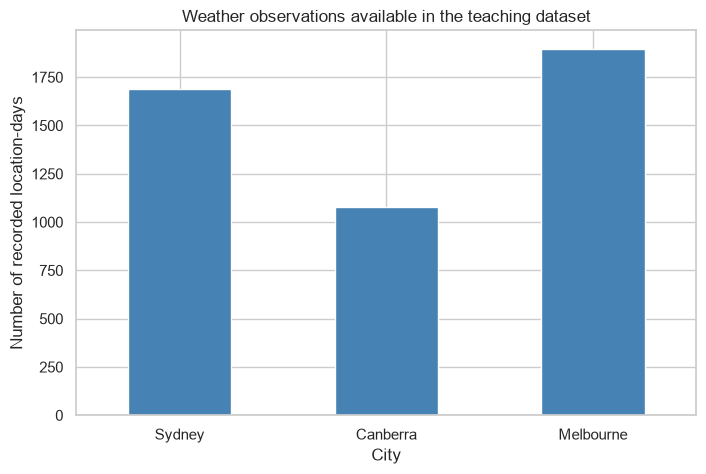

In [3]:
city_counts = city_weather["Location"].value_counts().reindex(cities)
city_counts.plot.bar(rot=0, color="steelblue")
plt.xlabel("City")
plt.ylabel("Number of recorded location-days")
plt.title("Weather observations available in the teaching dataset")
plt.show()

A proportion needs a denominator. Dividing these counts by their sum gives each city's share of the **selected rows**, not the chance of a particular weather event in that city.

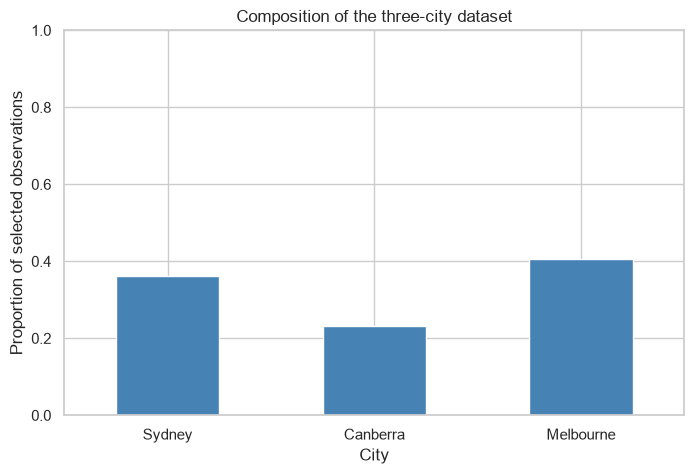

In [4]:
city_share = city_counts / city_counts.sum()
city_share.plot.bar(rot=0, color="steelblue")
plt.xlabel("City")
plt.ylabel("Proportion of selected observations")
plt.ylim(0, 1)
plt.title("Composition of the three-city dataset")
plt.show()

**Check your understanding:** Would twice as many rows from Sydney establish that Sydney has twice as many hot days? Explain what else you need to know.

### A First Histogram

A histogram groups numeric observations into intervals. Adjacent bars represent intervals on a numeric scale, unlike the separate categories of a bar chart. Inspect shape, center, spread, and unusual values before computing a single summary.

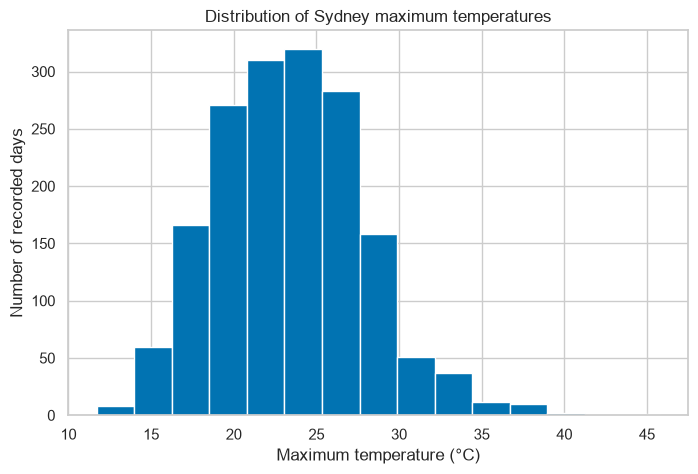

In [5]:
sydney = city_weather.loc[city_weather["Location"].eq("Sydney")].sort_values("Date")
sydney["MaxTemp"].plot.hist(bins=15, edgecolor="white", color=city_colors["Sydney"])
plt.xlabel("Maximum temperature (°C)")
plt.ylabel("Number of recorded days")
plt.title("Distribution of Sydney maximum temperatures")
plt.show()

**Try it:** Rerun with 5, 15, and 40 bins. Which features persist? Which apparent gaps or peaks depend on the bin choice? A roughly bell-shaped plot alone does not establish normality.

### Dates and Line Plots

Convert dates and sort them before connecting observations. You can use `x="Date"` or a datetime index; setting an index is not itself date conversion. This teaching file may omit days. A line connects the available observations and does not prove that intervening days were measured.

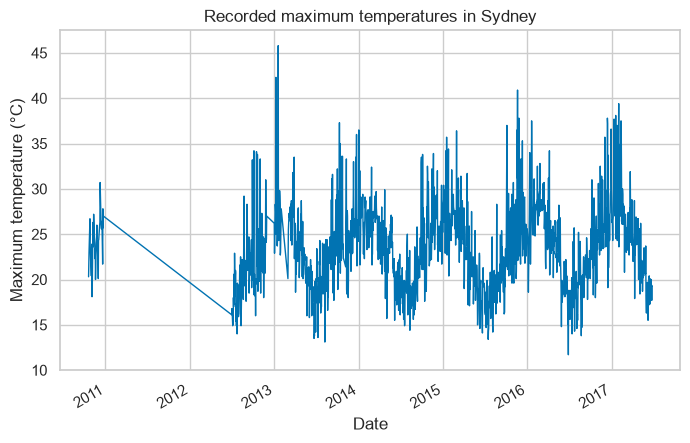

In [6]:
sydney.plot(x="Date", y="MaxTemp", legend=False, linewidth=1)
plt.xlabel("Date")
plt.ylabel("Maximum temperature (°C)")
plt.title("Recorded maximum temperatures in Sydney")
plt.show()

### Transfer: Historical COVID Counts

In `covid.csv`, one row is a date in the supplied historical series. Read its provenance before generalizing beyond that series. Compare a time plot with a distribution: the time plot preserves order, while the histogram does not.

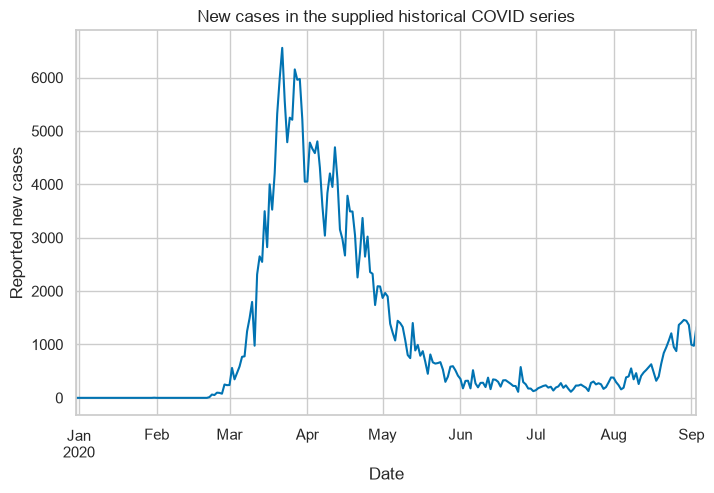

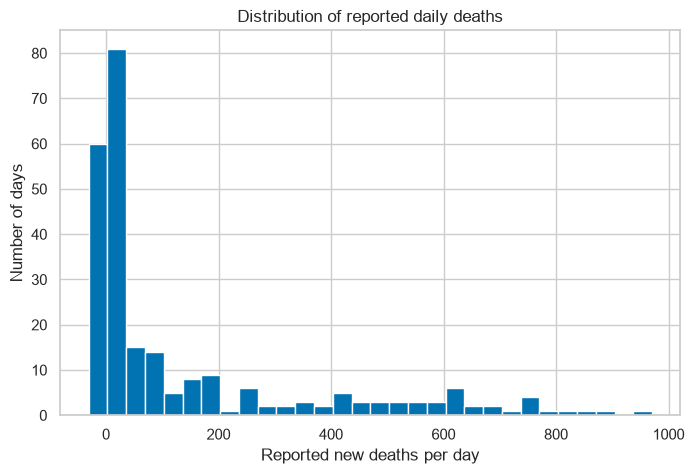

In [7]:
covid = pd.read_csv(DATA / "covid.csv", parse_dates=["date"]).sort_values("date")
covid.plot(x="date", y="new_cases", legend=False)
plt.xlabel("Date")
plt.ylabel("Reported new cases")
plt.title("New cases in the supplied historical COVID series")
plt.show()

covid["new_deaths"].plot.hist(bins=30, edgecolor="white")
plt.xlabel("Reported new deaths per day")
plt.ylabel("Number of days")
plt.title("Distribution of reported daily deaths")
plt.show()

The death-count distribution has a long tail toward large values: **right skew**. Skew is named for the tail, not for the side containing most observations. Unusual reports deserve investigation rather than automatic removal.

**Choose and explain:** New cases and deaths have different magnitudes. What might a shared vertical axis hide? Chapter 9 introduces separate panels. A same-day scatterplot also ignores the time lag between cases and deaths.

## Data Plotting with Matplotlib pyplot Interface {#data-plotting-with-matplotlib-pyplot-interface}

### Build a Labeled Plot

`plt` is the conventional name for `matplotlib.pyplot`. Pyplot sends commands to the current figure and plot area. Start a new example with `plt.figure()`; then draw, label, and display it. `plt.show()` displays the figure; a trailing semicolon is only a notebook convenience for hiding an object's text representation.

The following values are **illustrative**, not measured crop data. Supplying `years` prevents the horizontal axis from becoming row positions.

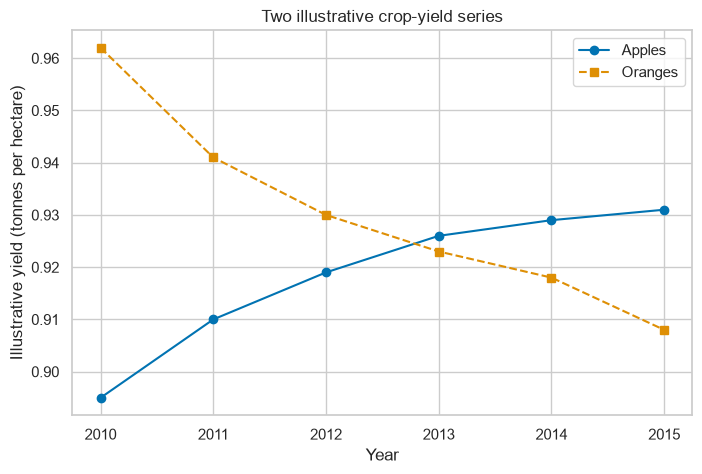

In [8]:
years = np.arange(2010, 2016)
apples = np.array([0.895, 0.910, 0.919, 0.926, 0.929, 0.931])
oranges = np.array([0.962, 0.941, 0.930, 0.923, 0.918, 0.908])
plt.figure(figsize=(8, 5))
plt.plot(years, apples, marker="o", label="Apples")
plt.plot(years, oranges, marker="s", linestyle="--", label="Oranges")
plt.xlabel("Year")
plt.ylabel("Illustrative yield (tonnes per hectare)")
plt.title("Two illustrative crop-yield series")
plt.legend()
plt.show()

### Style to Support Reading

| Parameter | Purpose | Example |
|---|---|---|
| `figsize` | Width and height in inches | `(8, 5)` |
| `color` | Encode a group or highlight | `"steelblue"` |
| `linestyle` | Distinguish lines without color alone | `"--"` |
| `marker` | Show individual measurements | `"o"` |
| `linewidth` | Control line prominence | `2` |
| `alpha` | Reveal overlap with transparency | `0.3` |

Use the same color for the same group across figures. Markers and line styles provide cues beyond color. Avoid assigning an unrelated color to every bar when color conveys no additional information.

**Scales matter:** Bar lengths encode magnitude and generally need a zero baseline. A line plot can use a narrower range to reveal variation, but the ticks and title must make the range clear. Ask how the apparent change in the crop example would differ with a zero baseline.

### Plot Data, Not Row Positions

Matplotlib takes numeric arrays or Series. For a scatterplot, pair the two variables from the same rows. Transparency reveals overlapping observations; it does not solve every problem in a dense plot.

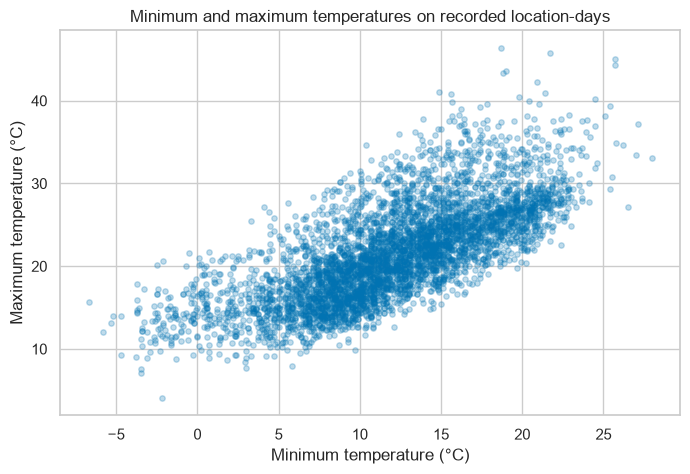

In [9]:
paired = city_weather.dropna(subset=["MinTemp", "MaxTemp"])
plt.figure(figsize=(8, 5))
plt.scatter(paired["MinTemp"], paired["MaxTemp"], s=15, alpha=0.25)
plt.xlabel("Minimum temperature (°C)")
plt.ylabel("Maximum temperature (°C)")
plt.title("Minimum and maximum temperatures on recorded location-days")
plt.show()

Describe direction, form, scatter, clusters, and unusual observations. These measurements refer to the same days; an association does not establish that changing one temperature would cause the other to change.

## Plotting with Seaborn {#plotting-with-seaborn}

### Map Variables to Visual Properties

Use `data=...` with column names. `hue` maps a variable to color; `style` can reinforce categorical distinctions with marker shapes. The same cities keep the same colors throughout the chapter.

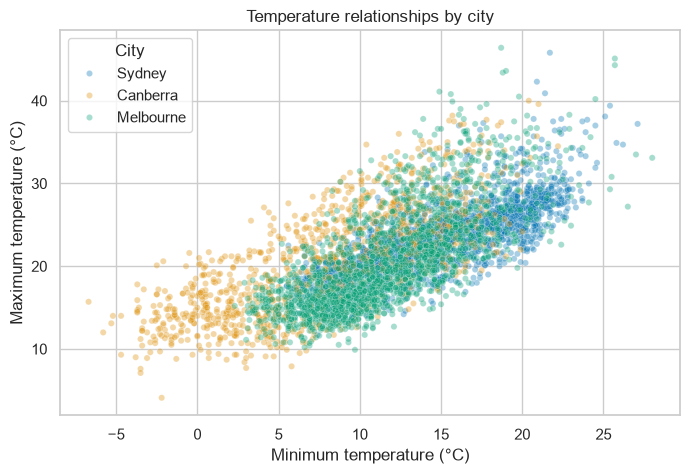

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=paired, x="MinTemp", y="MaxTemp", hue="Location",
                hue_order=cities, palette=city_colors, alpha=0.35, s=20)
plt.xlabel("Minimum temperature (°C)")
plt.ylabel("Maximum temperature (°C)")
plt.title("Temperature relationships by city")
plt.legend(title="City")
plt.show()

**Interpret:** Do the groups overlap? Does the overall pattern describe each city equally well? Do not call groups separable merely because they have different colors. Facets in Chapter 9 provide another way to inspect the same groups.

### Compare Distributions Fairly

With unequal sample sizes, histogram counts mix distribution shape and the amount of data available. Density scaling lets us compare shape: **area**, not the sum of bar heights, equals one for each group when `common_norm=False`. Density is not the probability of a single exact temperature.

Use shared bin edges for a fair comparison. Here each bin spans 3 °C.

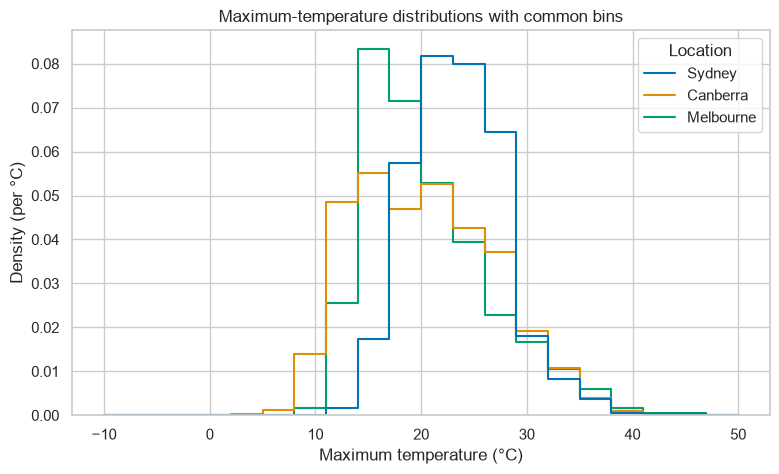

In [11]:
temperature_bins = np.arange(-10, 51, 3)
plt.figure(figsize=(9, 5))
sns.histplot(data=city_weather, x="MaxTemp", hue="Location", hue_order=cities,
             palette=city_colors, bins=temperature_bins, stat="density",
             common_norm=False, element="step", fill=False)
plt.xlabel("Maximum temperature (°C)")
plt.ylabel("Density (per °C)")
plt.title("Maximum-temperature distributions with common bins")
plt.show()

**Try it:** Change `stat="density"` to `stat="count"`. Use the setup table to explain why the two plots answer different questions. `common_norm=False` does not normalize a count histogram.

### Smooth Density Curves

A kernel density estimate (KDE) smooths a distribution. Its bandwidth controls smoothing; smaller bandwidths show more local detail and may emphasize noise. KDE is optional, not an automatic improvement to every histogram. It can extend into impossible values for bounded variables, such as negative rainfall.

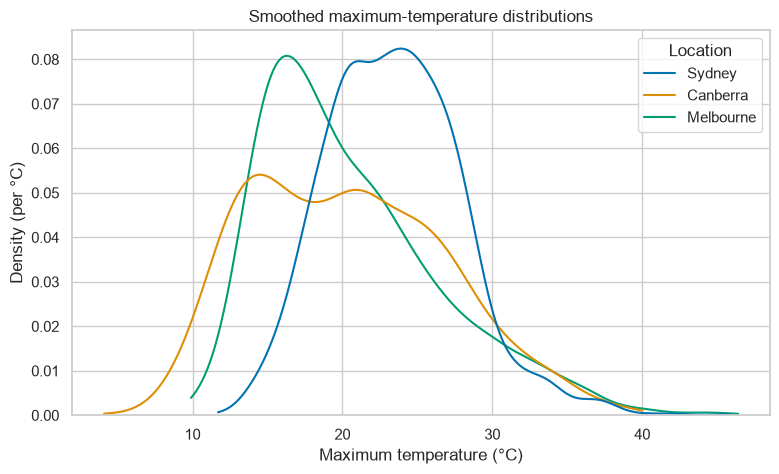

In [12]:
plt.figure(figsize=(9, 5))
sns.kdeplot(data=city_weather, x="MaxTemp", hue="Location", hue_order=cities,
            palette=city_colors, common_norm=False, bw_adjust=1, cut=0)
plt.xlabel("Maximum temperature (°C)")
plt.ylabel("Density (per °C)")
plt.title("Smoothed maximum-temperature distributions")
plt.show()

**Check:** Compare `bw_adjust=0.5` and `bw_adjust=2`. Which conclusions survive both choices? Different date coverage or seasons can explain city differences; these samples alone do not establish a difference in long-run climate.

### Boxplots: Summaries and Potential Outliers

The box runs from the first quartile (Q1) to the third quartile (Q3); its length is the interquartile range, IQR = Q3 − Q1. The line inside is the median. With the default rule, whiskers end at the most extreme observations within Q1 − 1.5 × IQR and Q3 + 1.5 × IQR. They do not necessarily reach the minimum and maximum, nor exactly the fences. Points beyond the whiskers are potential outliers, not automatically bad records.

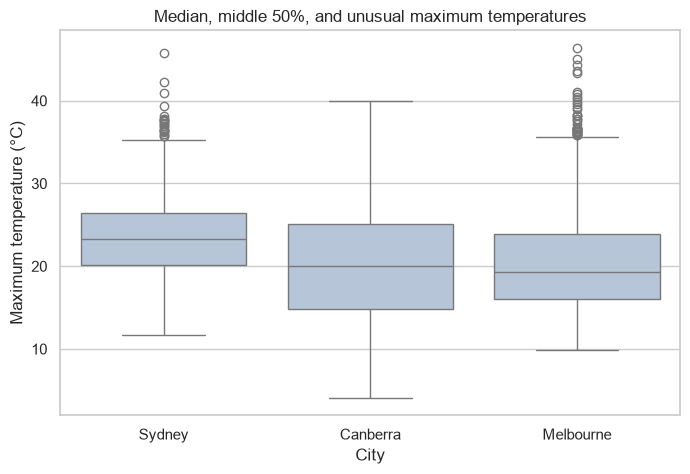

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=city_weather, x="Location", y="MaxTemp", order=cities,
            color="lightsteelblue")
plt.xlabel("City")
plt.ylabel("Maximum temperature (°C)")
plt.title("Median, middle 50%, and unusual maximum temperatures")
plt.show()

A boxplot makes medians and IQRs easy to compare, but hides sample size and much of the distribution's shape. A histogram can reveal multiple peaks that a boxplot conceals. Use both when that distinction matters.

### Counts, Supplied Values, and Estimated Means

These functions can produce similar-looking bars with different meanings:

| Function | Input | Bar height |
|---|---|---|
| `counts.plot.bar()` / `plt.bar(labels, values)` | Already summarized values | The supplied number |
| `sns.countplot(data=df, x="group")` | Individual rows | Number of rows per group |
| `sns.barplot(data=df, x="group", y="value")` | Individual rows | Mean of `value` by default |

Always state the statistic and observational unit. We now use the course survey: one row represents one respondent. The groups below are respondents' self-reported personality categories, not experimental assignments.

In [14]:
survey = pd.read_csv(DATA / "survey_data_clean.csv")
personality_order = ["Introvert", "Ambivert", "Extrovert"]
# Use the categories actually recorded in this file.
personality_order = [p for p in personality_order if p in survey["introvert_extrovert"].unique()]
marriage = survey.dropna(subset=["introvert_extrovert", "expected_marriage_age"])
marriage_summary = marriage.groupby("introvert_extrovert")["expected_marriage_age"].agg(["count", "mean", "std"])
marriage_summary.reindex(personality_order)

,count,mean,std
introvert_extrovert,,,
Introvert,105,29.838095,10.073885
Extrovert,78,28.307692,2.570096


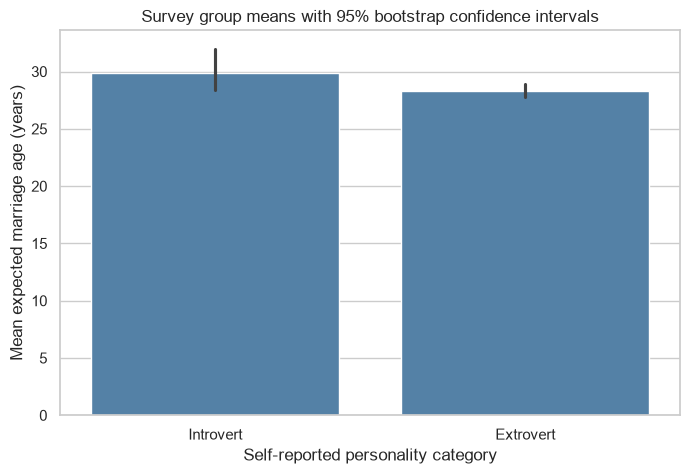

In [15]:
plt.figure(figsize=(8, 5))
sns.barplot(data=marriage, x="introvert_extrovert", y="expected_marriage_age",
            order=personality_order, estimator="mean", errorbar=("ci", 95),
            seed=303, color="steelblue")
plt.xlabel("Self-reported personality category")
plt.ylabel("Mean expected marriage age (years)")
plt.title("Survey group means with 95% bootstrap confidence intervals")
plt.show()

### Spread Is Different from Uncertainty

- `errorbar="sd"` shows the mean ± one standard deviation: variation among individual responses.
- `errorbar=("ci", 95)` shows a bootstrap confidence interval for the group mean: uncertainty in the estimate under the resampling assumptions.
- `errorbar=None` removes error bars; it does not make an estimate certain.

A confidence interval is not an interval containing 95% of individual responses. Its width depends on both variability and sample size. Resampling this convenience sample does not make it representative of all students. The seed makes bootstrap results reproducible.

**Try it:** Change the error bars to `"sd"`, then make a boxplot of the same data. Which display answers “How variable are responses?” Which answers “How uncertain is the estimated mean?” Include group counts in your explanation.

### Two Categorical Variables: Define the Denominator

For each city, what proportion of nonmissing `RainToday` records say Yes? A 100% stacked bar compares composition within a group. This uses a small cross-tabulation; later data-aggregation chapters develop the technique further.

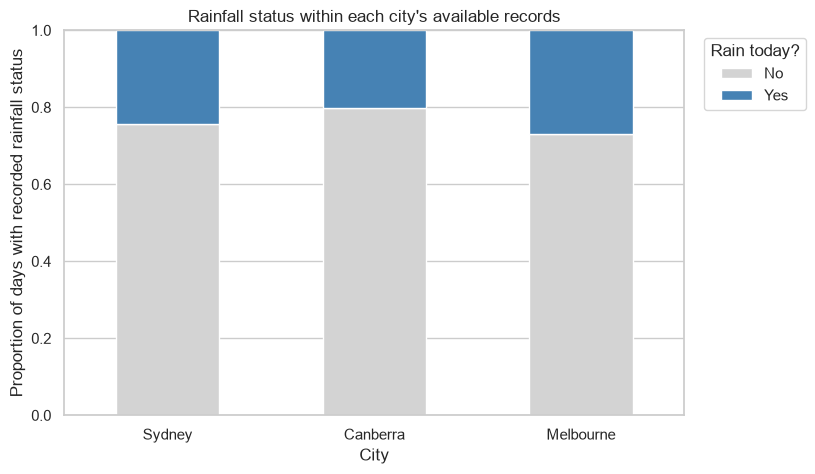

RainToday,No,Yes
Location,,
Sydney,1278,412
Canberra,859,219
Melbourne,1385,513


In [16]:
rain_rows = city_weather.dropna(subset=["RainToday"])
rain_counts = pd.crosstab(rain_rows["Location"], rain_rows["RainToday"]).reindex(cities)
rain_proportions = rain_counts.div(rain_counts.sum(axis=1), axis=0)
rain_proportions.plot.bar(stacked=True, rot=0, color=["lightgray", "steelblue"])
plt.xlabel("City")
plt.ylabel("Proportion of days with recorded rainfall status")
plt.ylim(0, 1)
plt.title("Rainfall status within each city's available records")
plt.legend(title="Rain today?", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()
rain_counts

The denominator is each city's number of nonmissing rainfall-status records. Missing status is excluded, not coded as No. A grouped count chart would answer a different question. Check the category labels and their order before choosing colors.

## Heatmaps and Correlation {#heatmaps-and-correlation}

### A Matrix Uses Color to Show Values

A heatmap can show many kinds of rectangular tables, not just correlations. Here each cell is a within-city rainfall proportion. A sequential palette represents low-to-high values; annotations provide exact values without relying on color alone.

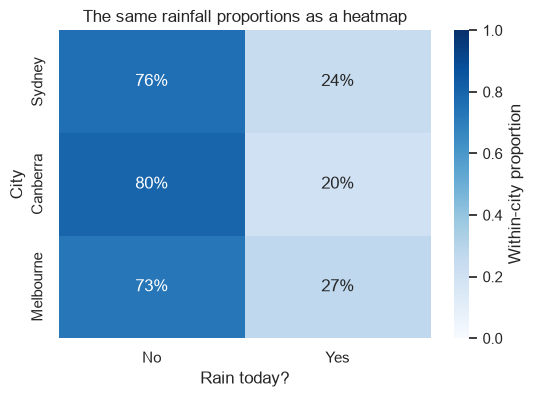

In [17]:
plt.figure(figsize=(6, 4))
sns.heatmap(rain_proportions, annot=True, fmt=".0%", cmap="Blues", vmin=0, vmax=1,
            cbar_kws={"label": "Within-city proportion"})
plt.xlabel("Rain today?")
plt.ylabel("City")
plt.title("The same rainfall proportions as a heatmap")
plt.show()

### Pearson Correlation Describes Linear Association

Pearson's correlation ranges from −1 to 1. Its sign gives direction; its absolute value measures the strength of linear association. Values near zero do not rule out a nonlinear relationship. Outliers and mixed groups can strongly affect it.

Choose meaningful numeric measurements rather than blindly including every numeric column (IDs and category codes may be numeric). Pairwise missing-value handling can give different sample sizes for different pairs; we use complete cases here so the matrix uses the same rows throughout.

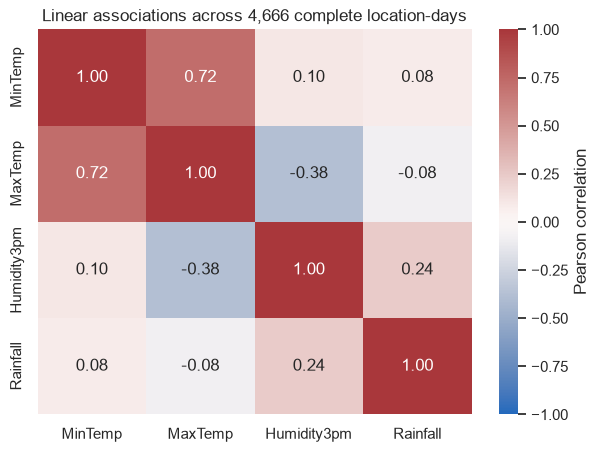

In [18]:
measurements = ["MinTemp", "MaxTemp", "Humidity3pm", "Rainfall"]
complete_weather = city_weather.dropna(subset=measurements)
corr = complete_weather[measurements].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, center=0,
            cbar_kws={"label": "Pearson correlation"})
plt.title(f"Linear associations across {len(complete_weather):,} complete location-days")
plt.show()

A diverging palette with limits −1 and 1 gives zero a consistent midpoint. The diagonal is 1 for variables with nonzero variance; the matrix is symmetric. Do not apply universal “weak/moderate/strong” cutoffs without considering context.

A scatterplot reveals features this matrix cannot show: curvature, clusters, unequal spread, and individual unusual points. Chapter 9's pairplots put those views together.

### Report the Value Before Interpreting It

The original survey example describes procrastination and GPA. Compute that association rather than assuming it is strong. The indicator is coded 0/1, so its interpretation depends on that coding; this is not evidence of a causal effect.

In [19]:
survey_pair = survey[["procrastinator", "NU_GPA"]].dropna()
r = survey_pair["procrastinator"].corr(survey_pair["NU_GPA"])
print(f"Procrastination indicator vs GPA: r = {r:.3f}, n = {len(survey_pair)}")

# Sort by absolute value for strength, retaining signed values for direction.
gpa_variables = ["NU_GPA", "sleep_hours_per_day", "minutes_ex_per_week", "parties_per_month"]
gpa_complete = survey[gpa_variables].dropna()
gpa_associations = gpa_complete.corr()["NU_GPA"].drop("NU_GPA")
gpa_associations.sort_values(key=lambda s: s.abs(), ascending=False)

Procrastination indicator vs GPA: r = -0.270, n = 177


sleep_hours_per_day    0.136945
minutes_ex_per_week   -0.107504
parties_per_month     -0.076990
Name: NU_GPA, dtype: float64

## Make a Figure Ready to Share {#make-a-figure-ready-to-share}

Check the title, units, denominator, readable text, meaningful colors, and axis scale. Use a descriptive title for exploration; a claim in a presentation title must be supported by the plotted data. Add a caption naming the source, date coverage, missing-data rule, and limitations when relevant.

Pandas and axes-level Seaborn functions return a Matplotlib `Axes`. Keep it as `ax`, then keep its parent figure for export. This is the bridge to Chapter 9's explicit interface.

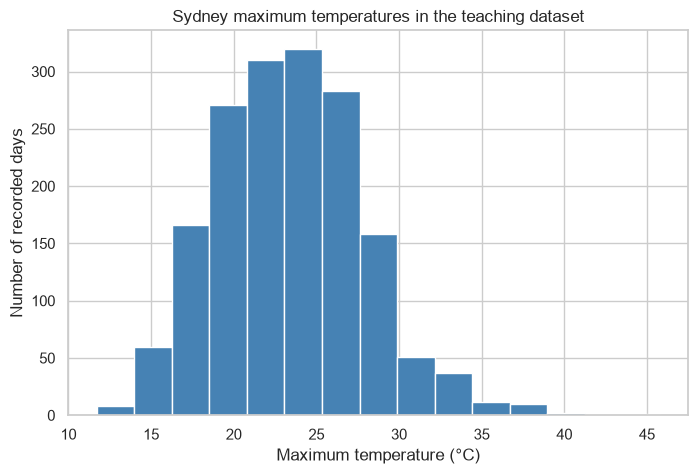

In [20]:
ax = sydney["MaxTemp"].plot.hist(bins=15, edgecolor="white", color="steelblue")
ax.set(xlabel="Maximum temperature (°C)", ylabel="Number of recorded days",
       title="Sydney maximum temperatures in the teaching dataset")
fig = ax.figure
plt.show()

Save the specific figure you created. PNG is convenient for slides; SVG preserves scalable lines and text for suitable graphics.

```python
fig.savefig("sydney-temperature.png", dpi=300, bbox_inches="tight")
fig.savefig("sydney-temperature.svg", bbox_inches="tight")
```

Higher DPI does not fix tiny labels, poor contrast, or a misleading scale. For multiple panels, use `fig, axes = plt.subplots(...)`, developed in the next chapter.

## Optional Reference: Additional Plotting Techniques {#optional-reference}

These examples broaden your toolkit for projects. They are not all required for a first reading.

### Matplotlib Bar and Box Plots with FIFA Data

Use label-based selection to keep category labels aligned with their counts. Do not assume the most common category will always occupy the first position. Ratings below describe players in this historical game dataset, not current team strength.

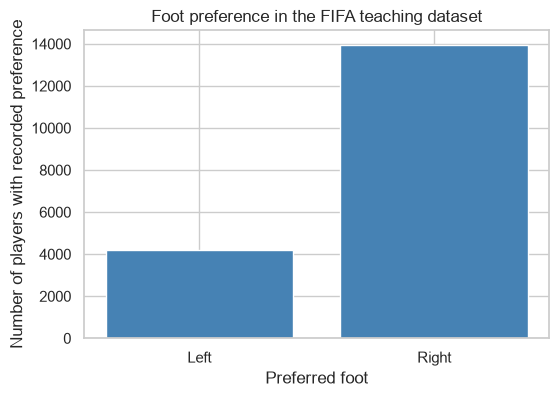

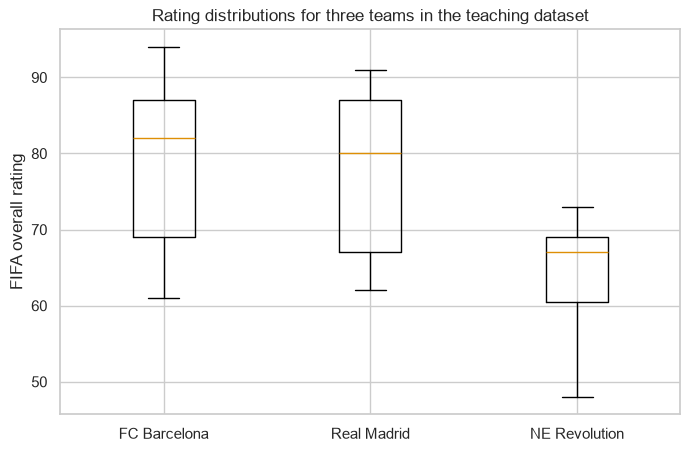

In [21]:
fifa = pd.read_csv(DATA / "fifa_data.csv")
foot_counts = fifa["Preferred Foot"].value_counts().reindex(["Left", "Right"], fill_value=0)
plt.figure(figsize=(6, 4))
plt.bar(foot_counts.index, foot_counts.values, color="steelblue")
plt.xlabel("Preferred foot")
plt.ylabel("Number of players with recorded preference")
plt.title("Foot preference in the FIFA teaching dataset")
plt.show()

teams = ["FC Barcelona", "Real Madrid", "New England Revolution"]
ratings = [fifa.loc[fifa["Club"].eq(team), "Overall"].dropna() for team in teams]
plt.figure(figsize=(8, 5))
plt.boxplot(ratings, tick_labels=["FC Barcelona", "Real Madrid", "NE Revolution"])
plt.ylabel("FIFA overall rating")
plt.title("Rating distributions for three teams in the teaching dataset")
plt.show()

### Pie Charts and Part-to-Whole Comparisons

A pie chart can show a small number of mutually exclusive parts of a whole. A bar chart is often easier for comparing similar values. Do not explode slices simply for decoration; check the denominator and rounding. Compare this display with the preceding foot-preference bars.

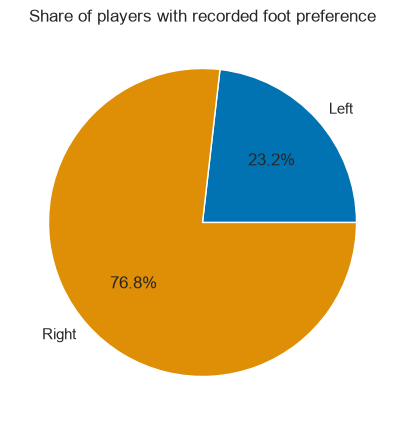

In [22]:
plt.figure(figsize=(5, 5))
plt.pie(foot_counts.values, labels=foot_counts.index, autopct="%.1f%%",
        colors=sns.color_palette("colorblind", 2))
plt.title("Share of players with recorded foot preference")
plt.show()

### Regression Lines and Their Intervals

`sns.regplot(data=df, x="x", y="y", ci=95)` fits a linear trend and shows a bootstrap confidence band for that trend. This is not a prediction interval for an individual observation. Repeated observations through time or within locations require more care than a simple independent-observation bootstrap. Chapter 9 uses the survey to practice fitting and comparing trends.

### Compact Function Reference

| Goal | Pandas | Matplotlib | Seaborn |
|---|---|---|---|
| Time series | `.plot(x=..., y=...)` | `plt.plot()` | `sns.lineplot()` |
| Two numeric variables | `.plot.scatter()` | `plt.scatter()` | `sns.scatterplot()` |
| Distribution | `.plot.hist()` | `plt.hist()` | `sns.histplot()` |
| Category counts | `.value_counts().plot.bar()` | `plt.bar()` on counts | `sns.countplot()` |
| Group means | Summarize, then plot | `plt.bar()` on means | `sns.barplot()` |
| Distribution by group | `.boxplot()` | `plt.boxplot()` | `sns.boxplot()` |
| Smooth distribution | `.plot.kde()` | — | `sns.kdeplot()` |
| Matrix | — | `plt.imshow()` | `sns.heatmap()` |

The functions are not identical: for example, Seaborn's `lineplot()` normally aggregates repeated x values and can add an uncertainty band. Inspect defaults whenever a function computes statistics for you.

## Independent Study {#independent-study}

For each task, submit the plot, a reason for the plot choice, two supported observations, and one limitation. Your code should run from a fresh kernel. Use the source data without overwriting the CSV files.

### Practice Exercise 1: Survey Comparisons

1. Compare expected marriage ages across the recorded personality categories. Show distributions and report usable group counts.
2. Create a plot of group means with 95% confidence intervals. Explain why those intervals differ from the spread in your first plot.
3. Add `love_first_sight` as a grouping variable. Which groups become small? How does that affect your interpretation?
4. Identify information missing from these plots that could change your conclusion. Consider sample selection, group sizes, and other respondent characteristics.

A two-category split is enough here. Add `procrastinator` as separate panels after learning faceting in Chapter 9.

In [23]:
# Your survey plots and explanations here.

### Practice Exercise 2: Weather Distributions and Relationships

1. Compare maximum-temperature distributions in Sydney, Canberra, and Melbourne. Choose counts or density deliberately and use common bins.
2. Make a KDE comparison. Change the bandwidth and identify a conclusion that is stable across your choices.
3. Compare the pooled distributions of minimum and maximum temperatures with **the same bin edges**. Explain what pooling across locations hides.
4. Plot minimum against maximum temperature, identify the observational unit, and describe the relationship. Explain why the observations do not justify a causal conclusion.

### Practice Exercise 3: Critique and Repair

Create two versions of one figure: a first attempt with a readability or comparison problem, and a revision. Consider bin widths, unequal group counts, overlapping points, category order, or a truncated bar baseline. Explain what you changed and how it changes what a reader can infer.

## Before You Move On {#before-you-move-on}

Can you explain what a point, bar, histogram bin, boxplot whisker, and confidence interval each represent? Can you identify the denominator and missing-data rule? Can you label and export a figure without overstating its evidence?

Next, [Data Visualization Intermediate](Advanced_Data_Visualization.ipynb) combines these individual plots into coherent comparisons and introduces maps for project work.

### Documentation

- [Pandas plotting](https://pandas.pydata.org/docs/user_guide/visualization.html)
- [Matplotlib boxplot definitions](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html)
- [Seaborn error bars: spread and uncertainty](https://seaborn.pydata.org/tutorial/error_bars.html)
- [Seaborn distribution plots](https://seaborn.pydata.org/tutorial/distributions.html)